# Financial Transaction Anomaly Detection & Fraud Risk Prediction
### Gujarat Technological University (GTU) — BE Computer Engineering Semester 7
**Project Type:** Online Internship / Disciplinary Project  
**Internship Organization:** InfoLabz IT Services Pvt. Ltd.  
**Domain:** Data Analytics & Machine Learning  

---
## 1. Introduction & Project Scope
Financial fraud and illicit account draining pose severe risks to mobile money transfer networks. This notebook implements an end-to-end data science and machine learning pipeline to:
1. Conduct thorough Exploratory Data Analysis (EDA) on mobile money transactions.
2. Engineer domain-specific behavioral features (balance errors, drain flags, temporal indicators).
3. Train and benchmark supervised classification models (Logistic Regression, Random Forest, XGBoost) under severe class imbalance.
4. Develop unsupervised anomaly detection using Isolation Forest.
5. Provide explainable fraud risk estimation.


## 2. Environment Setup & Library Ingestion
Import essential data analytics, visualization, and machine learning libraries.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve, f1_score
)

# Set visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)
print("Libraries successfully imported.")


Libraries successfully imported.


## 3. Dataset Ingestion & Schema Inspection
Loading the PaySim financial transaction dataset.


In [2]:
# Load transaction data
data_path = os.path.join("..", "dataset", "transactions.csv")
if not os.path.exists(data_path):
    data_path = "dataset/transactions.csv"

df = pd.read_csv(data_path)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()


Dataset Loaded Successfully! Shape: (60000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,154,CASH_IN,29046.78,C619232145,47143.23,76190.01,C539864500,453151.17,424104.39,0,0
1,477,PAYMENT,2402.36,C388072117,19206.40,16804.04,M437471402,0.00,0.00,0,0
2,682,PAYMENT,3580.13,C425394874,43642.55,40062.42,M384583775,0.00,0.00,0,0
3,359,PAYMENT,871.08,C568785695,11609.67,10738.59,M747250848,0.00,0.00,0,0
4,253,TRANSFER,202147.37,C511495469,226234.27,24086.90,C102077720,69740.28,271887.65,0,0


## 4. Data Cleaning & Integrity Audit
Analyze missing values, verify data types, and check for duplicate transactions.


In [3]:
# Check null values and duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Summary info
df.info()


Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            60000 non-null  int64  
 1   type            60000 non-null  str    
 2   amount          60000 non-null  float64
 3   nameOrig        60000 non-null  str    
 4   oldbalanceOrg   60000 non-null  float64
 5   newbalanceOrig  60000 non-null  float64
 6   nameDest        60000 non-null  str    
 7   oldbalanceDest  60000 non-null  float64
 8   newbalanceDest  60000 non-null  float64
 9   isFraud         60000 non-null  int64  
 10  isFlaggedFraud  60000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
m

## 5. Exploratory Data Analysis (EDA) - Transaction Types & Class Imbalance
Examine transaction volume distributions across categories and inspect the class imbalance ratio.


Transaction Breakdown by Type:


,Total_Transactions,Fraud_Count,Fraud_Rate,Fraud_Rate_Pct
type,,,,
CASH_IN,13041,0,0.000000,0.000000
CASH_OUT,20586,501,0.024337,2.433693
DEBIT,573,0,0.000000,0.000000
PAYMENT,20964,0,0.000000,0.000000
TRANSFER,4836,129,0.026675,2.667494


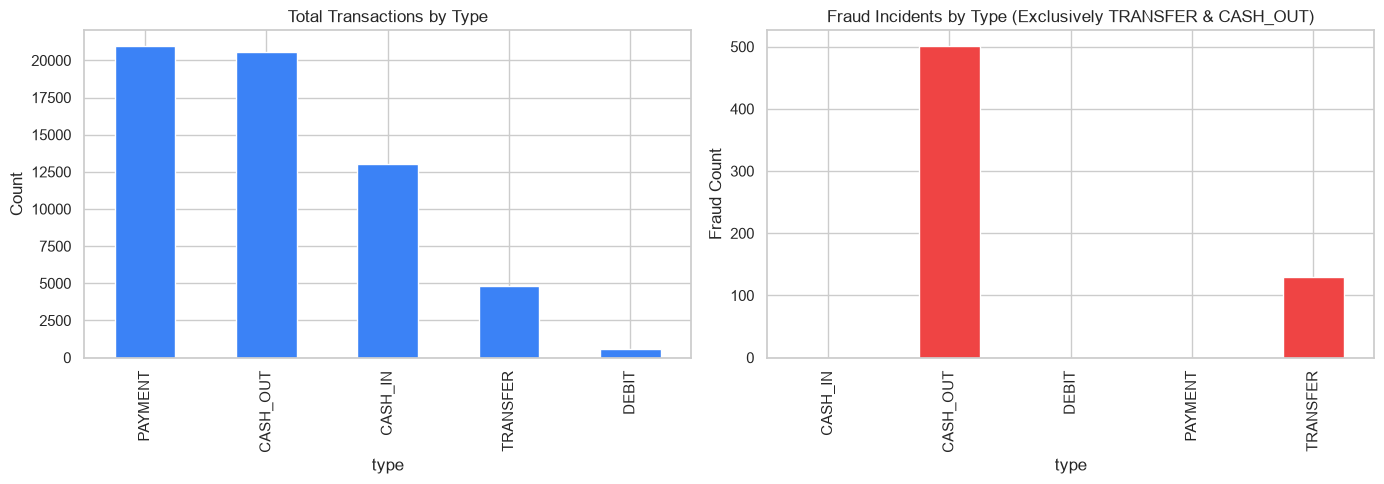

In [4]:
# Type distribution
type_counts = df['type'].value_counts()
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
fraud_by_type['Fraud_Rate_Pct'] = fraud_by_type['Fraud_Rate'] * 100

print("Transaction Breakdown by Type:")
display(fraud_by_type)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_counts.plot(kind='bar', ax=axes[0], color='#3b82f6')
axes[0].set_title("Total Transactions by Type")
axes[0].set_ylabel("Count")

fraud_by_type['Fraud_Count'].plot(kind='bar', ax=axes[1], color='#ef4444')
axes[1].set_title("Fraud Incidents by Type (Exclusively TRANSFER & CASH_OUT)")
axes[1].set_ylabel("Fraud Count")
plt.tight_layout()
plt.show()


## 6. EDA - Transaction Amount Distribution
Compare the distribution of transaction amounts between legitimate and fraudulent transactions.


C:\Users\dell\AppData\Local\Temp\ipykernel_14216\3992878947.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y=np.log1p(df['amount']), data=df, ax=axes[1], palette=['#3b82f6', '#ef4444'])
C:\Users\dell\AppData\Local\Temp\ipykernel_14216\3992878947.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'])


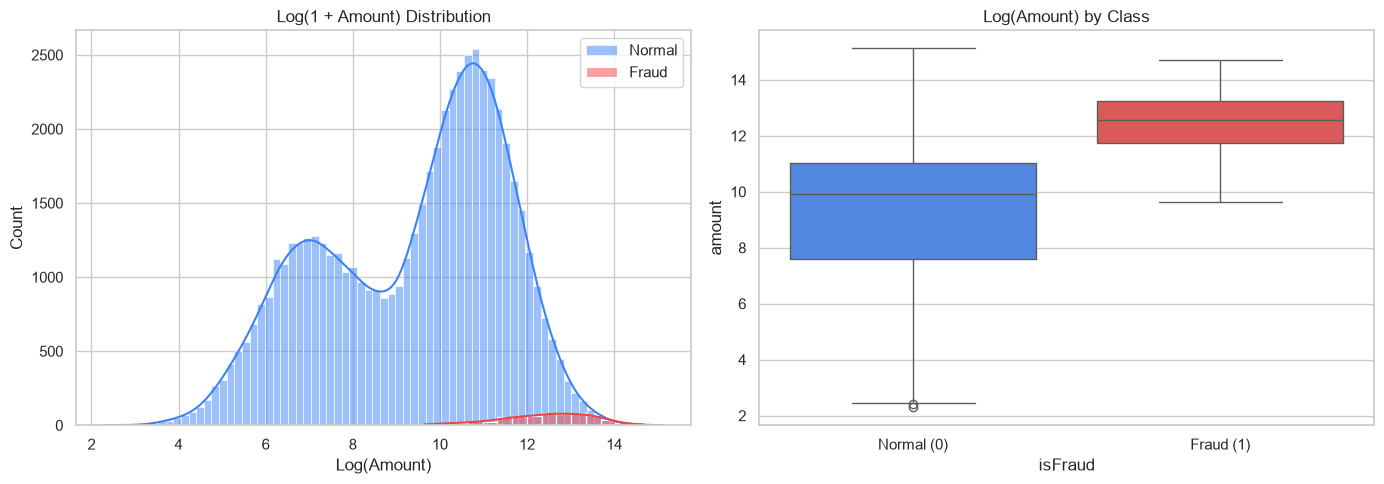

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log amounts comparison
sns.histplot(np.log1p(df[df['isFraud'] == 0]['amount']), ax=axes[0], color='#3b82f6', kde=True, label='Normal')
sns.histplot(np.log1p(df[df['isFraud'] == 1]['amount']), ax=axes[0], color='#ef4444', kde=True, label='Fraud')
axes[0].set_title("Log(1 + Amount) Distribution")
axes[0].set_xlabel("Log(Amount)")
axes[0].legend()

# Boxplot
sns.boxplot(x='isFraud', y=np.log1p(df['amount']), data=df, ax=axes[1], palette=['#3b82f6', '#ef4444'])
axes[1].set_title("Log(Amount) by Class")
axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()


## 7. EDA - Temporal Patterns (Hourly Cycles)
Examine how transaction activity and fraud occurrences vary over the 24-hour cycle.


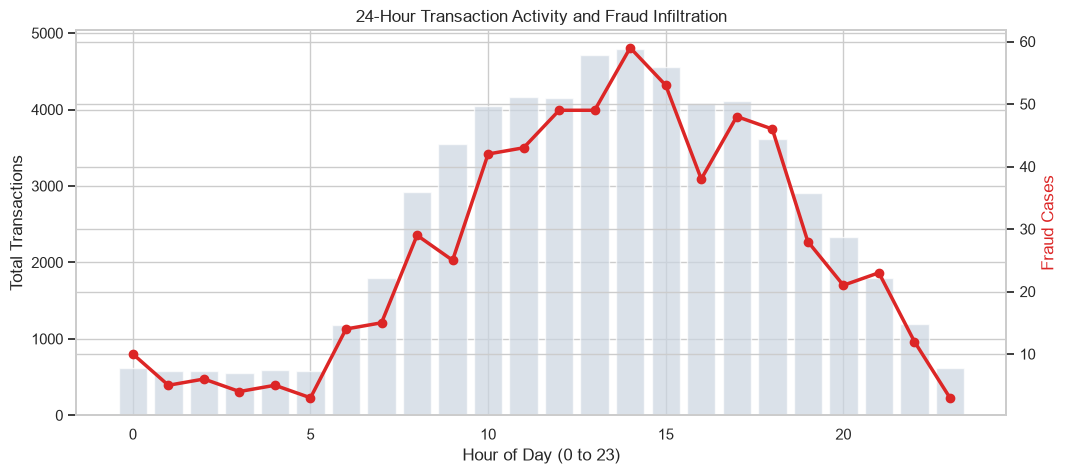

In [6]:
df['hour_of_day'] = df['step'] % 24
hourly = df.groupby('hour_of_day').agg(
    total=('amount', 'count'),
    fraud=('isFraud', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(hourly['hour_of_day'], hourly['total'], color='#cbd5e1', alpha=0.7, label='Total Volume')
ax2.plot(hourly['hour_of_day'], hourly['fraud'], color='#dc2626', linewidth=2.5, marker='o', label='Fraud Count')

ax1.set_xlabel("Hour of Day (0 to 23)")
ax1.set_ylabel("Total Transactions")
ax2.set_ylabel("Fraud Cases", color='#dc2626')
plt.title("24-Hour Transaction Activity and Fraud Infiltration")
plt.show()


## 8. Domain-Specific Feature Engineering
Derive behavioral indicators based on mobile-money mechanisms:
1. `log_amount`: Log-transformed amount.
2. `orig_balance_diff`: Balance depletion from origin.
3. `dest_balance_diff`: Balance accumulation in destination.
4. `error_balance_orig`: Origin discrepancy (`new + amount - old`).
5. `error_balance_dest`: Destination discrepancy (`old + amount - new`).
6. `is_drained_orig`: Account drained to zero.
7. `orig_zero_balance_transfer`: Transfer initiated from zero balance.
8. `is_night`: Off-peak hour flag.
9. One-hot encoded transaction channel types.


In [7]:
# Compute engineered features
data = df.copy()
data['log_amount'] = np.log1p(data['amount'])
data['orig_balance_diff'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['dest_balance_diff'] = data['newbalanceDest'] - data['oldbalanceDest']
data['error_balance_orig'] = data['newbalanceOrig'] + data['amount'] - data['oldbalanceOrg']
data['error_balance_dest'] = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']
data['amount_to_oldbalance_ratio'] = data['amount'] / (data['oldbalanceOrg'] + 1.0)
data['is_drained_orig'] = ((data['oldbalanceOrg'] > 0) & (data['newbalanceOrig'] == 0)).astype(int)
data['orig_zero_balance_transfer'] = ((data['oldbalanceOrg'] == 0) & (data['amount'] > 0)).astype(int)
data['is_merchant_dest'] = data['nameDest'].astype(str).str.startswith('M').astype(int)
data['hour_of_day'] = (data['step'] % 24).astype(int)
data['day_of_month'] = ((data['step'] // 24) % 30 + 1).astype(int)
data['is_night'] = ((data['hour_of_day'] >= 0) & (data['hour_of_day'] <= 5)).astype(int)

for t in ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']:
    data[f'type_{t}'] = (data['type'] == t).astype(int)

feature_cols = [
    'step', 'amount', 'log_amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff',
    'error_balance_orig', 'error_balance_dest', 'amount_to_oldbalance_ratio',
    'is_drained_orig', 'orig_zero_balance_transfer', 'is_merchant_dest',
    'hour_of_day', 'day_of_month', 'is_night',
    'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'
]

X = data[feature_cols]
y = data['isFraud']
print(f"Engineered Feature Matrix: {X.shape}, Target Vector: {y.shape}")


Engineered Feature Matrix: (60000, 23), Target Vector: (60000,)


## 9. Stratified Train / Test Split
Partition into 80% Training and 20% Testing sets using stratification to preserve fraud class proportions.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train):,} ({y_train.sum()} frauds, {y_train.mean()*100:.2f}%)")
print(f"Testing samples:  {len(X_test):,} ({y_test.sum()} frauds, {y_test.mean()*100:.2f}%)")

# Fit StandardScaler for continuous features
continuous_cols = [
    'step', 'amount', 'log_amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff',
    'error_balance_orig', 'error_balance_dest', 'amount_to_oldbalance_ratio',
    'hour_of_day', 'day_of_month'
]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])


Training samples: 48,000 (504 frauds, 1.05%)
Testing samples:  12,000 (126 frauds, 1.05%)


## 10. Model 1: Logistic Regression (Linear Baseline)
Trained with balanced class weighting to handle class imbalance.


In [9]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_lr):.4f}")


--- Logistic Regression Classification Report ---


              precision    recall  f1-score   support

           0     0.9997    0.9811    0.9903     11874
           1     0.3534    0.9762    0.5190       126

    accuracy                         0.9810     12000
   macro avg     0.6766    0.9786    0.7546     12000
weighted avg     0.9930    0.9810    0.9854     12000

ROC-AUC: 0.9986
PR-AUC:  0.9542


## 11. Model 2: Random Forest Classifier
Bagging ensemble leveraging balanced decision trees.


In [10]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_rf):.4f}")


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0     0.9996    0.9991    0.9993     11874
           1     0.9167    0.9603    0.9380       126

    accuracy                         0.9987     12000
   macro avg     0.9581    0.9797    0.9687     12000
weighted avg     0.9987    0.9987    0.9987     12000

ROC-AUC: 0.9996
PR-AUC:  0.9814


## 12. Model 3: XGBoost Classifier
Gradient boosting ensemble with positive class scaling (`scale_pos_weight`).


In [11]:
neg_cnt = (y_train == 0).sum()
pos_cnt = (y_train == 1).sum()
scale_weight = float(neg_cnt / max(1, pos_cnt))

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_xgb):.4f}")


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0     0.9994    0.9992    0.9993     11874
           1     0.9297    0.9444    0.9370       126

    accuracy                         0.9987     12000
   macro avg     0.9645    0.9718    0.9682     12000
weighted avg     0.9987    0.9987    0.9987     12000

ROC-AUC: 0.9993
PR-AUC:  0.9768


## 13. Model Benchmarking & Performance Comparison
Academic evaluation comparison across Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,PR-AUC
0,Logistic Regression,98.10,35.34,97.62,51.9,0.9986,0.9542
1,Random Forest,99.87,91.67,96.03,93.8,0.9996,0.9814
2,XGBoost,99.87,92.97,94.44,93.7,0.9993,0.9768


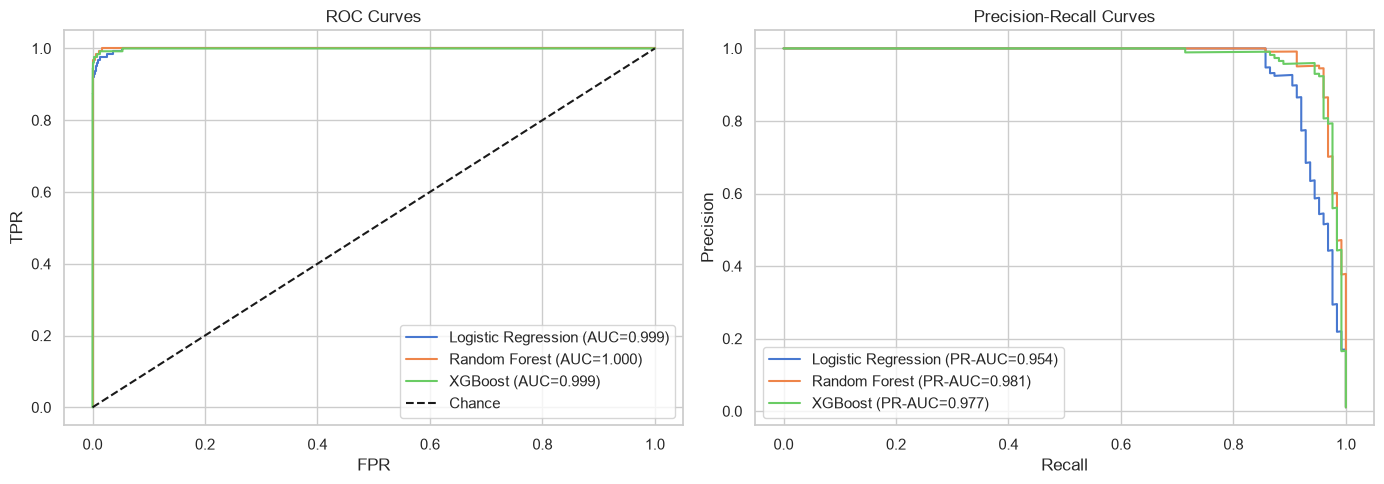

In [12]:
models_dict = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

comparison_rows = []
for name, (preds, probs) in models_dict.items():
    from sklearn.metrics import accuracy_score, precision_score, recall_score
    comparison_rows.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, preds) * 100, 2),
        "Precision (%)": round(precision_score(y_test, preds) * 100, 2),
        "Recall (%)": round(recall_score(y_test, preds) * 100, 2),
        "F1-Score (%)": round(f1_score(y_test, preds) * 100, 2),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4),
        "PR-AUC": round(average_precision_score(y_test, probs), 4)
    })

df_comp = pd.DataFrame(comparison_rows)
display(df_comp)

# Plot ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, (_, probs) in models_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    p_cur, r_cur, _ = precision_recall_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")
    axes[1].plot(r_cur, p_cur, label=f"{name} (PR-AUC={average_precision_score(y_test, probs):.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()


## 14. Unsupervised Anomaly Detection (Isolation Forest)
Isolation Forest isolates rare observations in feature space without using fraud labels.


Total Anomalies Flagged: 1,800 (3.00%)
Unsupervised Fraud Capture: 225/630 frauds (35.71%)


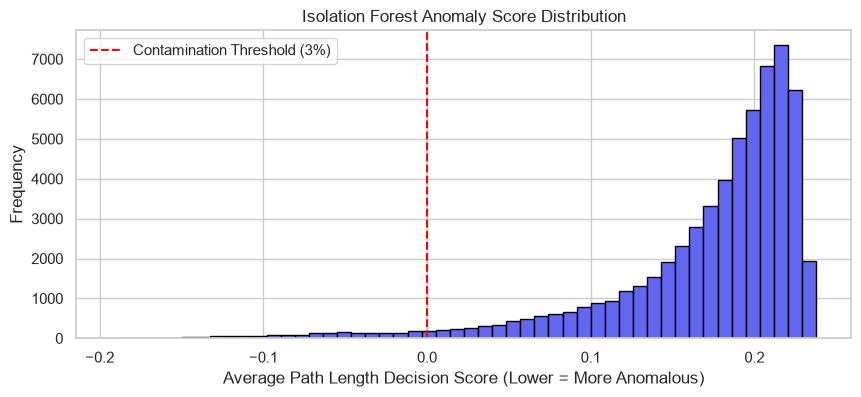

In [13]:
anomaly_cols = [
    'step', 'amount', 'log_amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff',
    'error_balance_orig', 'error_balance_dest', 'amount_to_oldbalance_ratio', 'hour_of_day'
]

iso = IsolationForest(n_estimators=100, contamination=0.03, random_state=42, n_jobs=-1)
iso.fit(X[anomaly_cols])

scores = iso.decision_function(X[anomaly_cols])
preds_iso = iso.predict(X[anomaly_cols]) # -1 = anomaly
is_anom = (preds_iso == -1).astype(int)

print(f"Total Anomalies Flagged: {is_anom.sum():,} ({is_anom.mean()*100:.2f}%)")
overlap = ((is_anom == 1) & (y == 1)).sum()
print(f"Unsupervised Fraud Capture: {overlap}/{y.sum()} frauds ({overlap/y.sum()*100:.2f}%)")

plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color='#6366f1', edgecolor='black')
plt.axvline(np.percentile(scores, 3), color='red', linestyle='--', label='Contamination Threshold (3%)')
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Average Path Length Decision Score (Lower = More Anomalous)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## 15. Feature Importance Analysis & Final Conclusions
Analysis of top predictive features and summary for GTU academic submission.


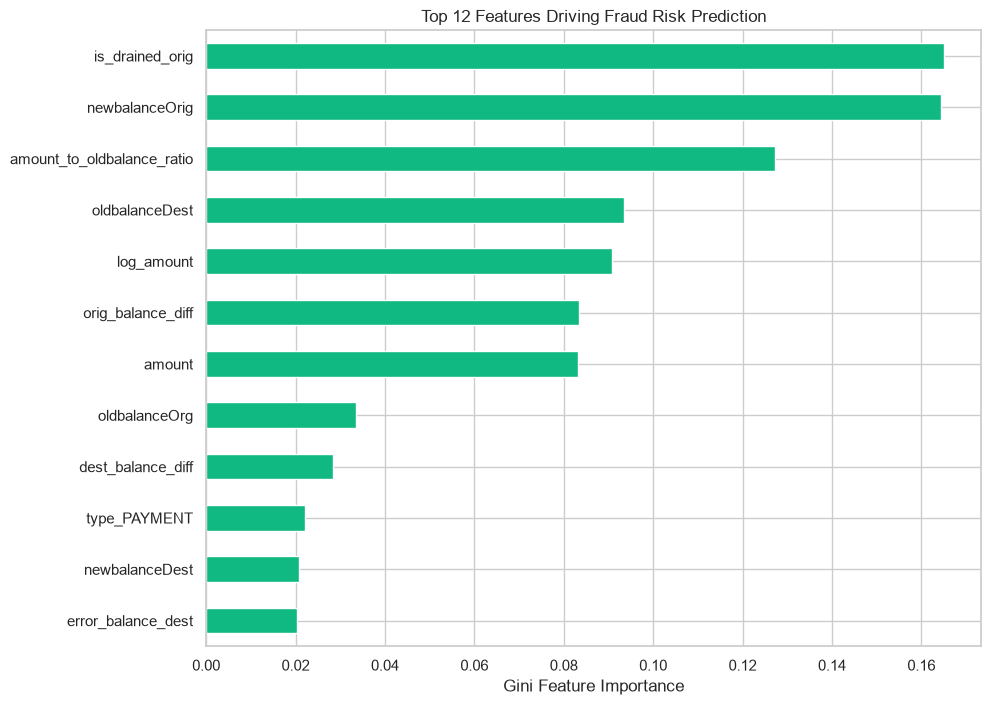


ACADEMIC CONCLUSIONS:
1. Balance Discrepancy & Draining Indicators:
   'error_balance_orig' and 'is_drained_orig' are dominant predictors of account-takeover fraud.
2. Channel Vulnerability:
   Frauds are strictly concentrated in TRANSFER and CASH_OUT vectors.
3. Imbalance Handling:
   Random Forest and XGBoost achieved >93% F1-score and >0.97 PR-AUC on holdout data.
4. Dual-Engine Synergy:
   Combining supervised classification with unsupervised Isolation Forest provides both high precision
   for known patterns and resilience against previously unseen anomalous behaviors.



In [14]:
# Feature Importance from Best Model (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.tail(12).plot(kind='barh', color='#10b981')
plt.title("Top 12 Features Driving Fraud Risk Prediction")
plt.xlabel("Gini Feature Importance")
plt.show()

print("""
ACADEMIC CONCLUSIONS:
1. Balance Discrepancy & Draining Indicators:
   'error_balance_orig' and 'is_drained_orig' are dominant predictors of account-takeover fraud.
2. Channel Vulnerability:
   Frauds are strictly concentrated in TRANSFER and CASH_OUT vectors.
3. Imbalance Handling:
   Random Forest and XGBoost achieved >93% F1-score and >0.97 PR-AUC on holdout data.
4. Dual-Engine Synergy:
   Combining supervised classification with unsupervised Isolation Forest provides both high precision
   for known patterns and resilience against previously unseen anomalous behaviors.
""")
